In [2]:
import os
import glob
import math
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm

# ==========================================
# 1. FIND XML FILES
# ==========================================
xml_files = glob.glob("/kaggle/input/**/*.xml", recursive=True)
print(f"Found {len(xml_files)} XML files to process.")

# ==========================================
# 2. XML PARSER FUNCTION
# ==========================================
def parse_ohio_xml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()

    cgm_data = []
    for event in root.findall('.//glucose_level/event'):
        cgm_data.append({
            'timestamp': event.get('ts'),
            'cgm': float(event.get('value'))
        })
    df_cgm = pd.DataFrame(cgm_data)
    if df_cgm.empty:
        return None

    df_cgm['timestamp'] = pd.to_datetime(df_cgm['timestamp'], format='%d-%m-%Y %H:%M:%S')
    df_cgm = df_cgm.sort_values('timestamp').drop_duplicates('timestamp')

    bolus_data = []
    for event in root.findall('.//insulin/event'):
        bolus_data.append({
            'timestamp': event.get('ts_begin'),
            'dose': float(event.get('dose'))
        })
    df_bolus = pd.DataFrame(bolus_data)
    if not df_bolus.empty:
        df_bolus['timestamp'] = pd.to_datetime(df_bolus['timestamp'], format='%d-%m-%Y %H:%M:%S')

    meal_data = []
    for event in root.findall('.//meal/event'):
        meal_data.append({
            'timestamp': event.get('ts'),
            'carbs': float(event.get('carbs'))
        })
    df_meals = pd.DataFrame(meal_data)
    if not df_meals.empty:
        df_meals['timestamp'] = pd.to_datetime(df_meals['timestamp'], format='%d-%m-%Y %H:%M:%S')

    df_cgm.set_index('timestamp', inplace=True)
    df_resampled = df_cgm.resample('5min').mean()
    df_resampled['cgm'] = df_resampled['cgm'].interpolate(method='linear')

    if not df_bolus.empty:
        df_bolus.set_index('timestamp', inplace=True)
        df_resampled = df_resampled.join(df_bolus.resample('5min').sum(), rsuffix='_bolus')
    else:
        df_resampled['dose'] = 0.0

    if not df_meals.empty:
        df_meals.set_index('timestamp', inplace=True)
        df_resampled = df_resampled.join(df_meals.resample('5min').sum(), rsuffix='_meal')
    else:
        df_resampled['carbs'] = 0.0

    df_resampled.fillna(0.0, inplace=True)
    return df_resampled.reset_index()

# ==========================================
# 3. BUILD DATASET TENSORS (x_main, x_base, x_time, y_target)
# ==========================================
def prepare_tensors_from_xmls(file_list, window_size=48, ph_steps=6, sigma=1.0):
    all_x_main, all_x_base, all_x_time, all_y = [], [], [], []

    for file_path in tqdm(file_list, desc="Parsing XML Files"):
        df = parse_ohio_xml(file_path)
        if df is None or len(df) <= (window_size + ph_steps):
            continue

        df['cgm_smooth'] = gaussian_filter1d(df['cgm'].values, sigma=sigma)

        timestamps = pd.to_datetime(df['timestamp'])
        sin_hour = np.sin(2 * np.pi * timestamps.dt.hour / 24.0)
        cos_hour = np.cos(2 * np.pi * timestamps.dt.hour / 24.0)
        sin_day = np.sin(2 * np.pi * timestamps.dt.dayofweek / 7.0)
        cos_day = np.cos(2 * np.pi * timestamps.dt.dayofweek / 7.0)
        sin_month = np.sin(2 * np.pi * timestamps.dt.month / 12.0)
        cos_month = np.cos(2 * np.pi * timestamps.dt.month / 12.0)
        time_feats = np.stack([sin_hour, cos_hour, sin_day, cos_day, sin_month, cos_month], axis=1)

        main_numeric = df[['cgm', 'cgm_smooth', 'dose', 'carbs']].values
        scaler = MinMaxScaler()
        main_scaled = scaler.fit_transform(main_numeric)
        
        padding_main = np.zeros((len(main_scaled), 4))
        main_feats = np.hstack([main_scaled, padding_main])
        base_feats = np.zeros((len(df), 7))
        target = df['cgm'].values

        for i in range(len(df) - window_size - ph_steps + 1):
            all_x_main.append(main_feats[i : i + window_size])
            all_x_base.append(base_feats[i : i + window_size])
            all_x_time.append(time_feats[i : i + window_size])
            all_y.append(target[i + window_size + ph_steps - 1])

    return (
        torch.tensor(np.array(all_x_main), dtype=torch.float32),
        torch.tensor(np.array(all_x_base), dtype=torch.float32),
        torch.tensor(np.array(all_x_time), dtype=torch.float32),
        torch.tensor(np.array(all_y), dtype=torch.float32)
    )

# Execute tensor build explicitly
x_main, x_base, x_time, y_target = prepare_tensors_from_xmls(xml_files)
print(f"Features created successfully: {x_main.shape[0]} total samples.")

# ==========================================
# 4. MODEL DEFINITION
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class PureLSTMGlucosePredictor(nn.Module):
    def __init__(self, main_dim=8, base_dim=7, time_dim=6, embed_dim=32, hidden_dim=128, num_layers=2):
        super(PureLSTMGlucosePredictor, self).__init__()
        self.linear_main = nn.Linear(main_dim, embed_dim)
        self.linear_base = nn.Linear(base_dim, embed_dim)
        self.conv_time = nn.Conv1d(in_channels=time_dim, out_channels=embed_dim, kernel_size=3, stride=1, padding=1)
        self.dim_reduction = nn.Linear(embed_dim * 3, embed_dim)
        self.pos_encoder = PositionalEncoding(d_model=embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )

        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x_main, x_base, x_time):
        e_main = self.linear_main(x_main)
        e_base = self.linear_base(x_base)
        e_time = self.conv_time(x_time.transpose(1, 2)).transpose(1, 2)

        fused_features = torch.cat([e_main, e_base, e_time], dim=-1)
        fused_embeddings = self.dim_reduction(fused_features)
        fused_embeddings = self.pos_encoder(fused_embeddings)

        lstm_out, _ = self.lstm(fused_embeddings)
        last_step_out = lstm_out[:, -1, :]

        out = self.fc1(last_step_out)
        out = self.relu(out)
        prediction = self.fc2(out)
        return prediction

# ==========================================
# 5. TRAINING & EVALUATION LOOP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

dataset = TensorDataset(x_main, x_base, x_time, y_target)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

model = PureLSTMGlucosePredictor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 60

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False)
    
    for b_main, b_base, b_time, b_y in train_bar:
        b_main, b_base, b_time, b_y = b_main.to(device), b_base.to(device), b_time.to(device), b_y.to(device)
        
        optimizer.zero_grad()
        preds = model(b_main, b_base, b_time)
        loss = criterion(preds.squeeze(), b_y)
        loss.backward()
        optimizer.step()
        
        loss_val = loss.item()
        running_loss += loss_val * b_main.size(0)
        train_bar.set_postfix(batch_loss=f"{loss_val:.4f}")
        
    epoch_loss = running_loss / train_size
    print(f"Epoch [{epoch}/{epochs}] Complete - Avg Loss (MSE): {epoch_loss:.4f}")

# Final Test Set Evaluation
model.eval()
test_loss = 0.0
test_bar = tqdm(test_loader, desc="Evaluating on Test Set", leave=False)

with torch.no_grad():
    for b_main, b_base, b_time, b_y in test_bar:
        b_main, b_base, b_time, b_y = b_main.to(device), b_base.to(device), b_time.to(device), b_y.to(device)
        preds = model(b_main, b_base, b_time)
        loss = criterion(preds.squeeze(), b_y)
        test_loss += loss.item() * b_main.size(0)

final_mse = test_loss / test_size
final_rmse = np.sqrt(final_mse)

print("\n--- Training Finished ---")
print(f"Test Set RMSE: {final_rmse:.3f} mg/dL")

Found 12 XML files to process.


Parsing XML Files:   0%|          | 0/12 [00:00<?, ?it/s]

Features created successfully: 92011 total samples.
Using device: cuda



Epoch 1/60 [Train]:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch [1/60] Complete - Avg Loss (MSE): 26283.3337


...

Epoch [59/60] Complete - Avg Loss (MSE): 314.5131


Epoch 60/60 [Train]:   0%|          | 0/576 [00:00<?, ?it/s]

Epoch [60/60] Complete - Avg Loss (MSE): 310.8182


Evaluating on Test Set:   0%|          | 0/144 [00:00<?, ?it/s]


--- Training Finished ---
Test Set RMSE: 17.544 mg/dL


          TEST SET RESULTS                
Root Mean Squared Error (RMSE): 17.544 mg/dL
Mean Absolute Error     (MAE) : 12.329 mg/dL



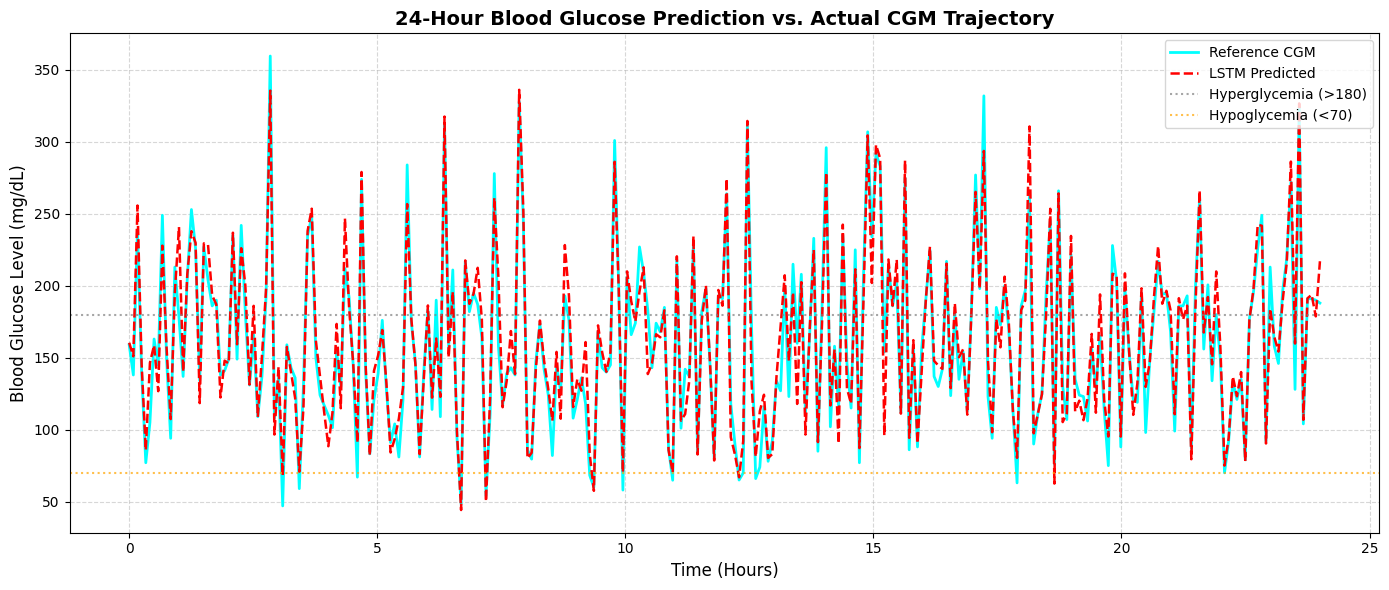

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ==========================================
# 1. TEST SET EVALUATION (RMSE & MAE)
# ==========================================
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for b_main, b_base, b_time, b_y in test_loader:
        b_main = b_main.to(device)
        b_base = b_base.to(device)
        b_time = b_time.to(device)
        
        # Forward pass prediction
        preds = model(b_main, b_base, b_time).squeeze()
        
        # Store predictions and actual ground truth targets
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(b_y.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Compute Mean Squared Error, Root Mean Squared Error, and Mean Absolute Error
mse = np.mean((all_preds - all_targets) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(all_preds - all_targets))

print("==========================================")
print("          TEST SET RESULTS                ")
print("==========================================")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f} mg/dL")
print(f"Mean Absolute Error     (MAE) : {mae:.3f} mg/dL")
print("==========================================\n")

# ==========================================
# 2. 24-HOUR PREDICTION TRAJECTORY PLOT
# ==========================================
# Extract a continuous 24-hour slice (288 steps of 5-minute intervals = 24 hours)
sample_window = 288 

if len(all_targets) >= sample_window:
    plt.figure(figsize=(14, 6))
    
    # Time steps formatted as hours (0 to 24 hours)
    time_axis = np.linspace(0, 24, sample_window)
    
    # Plot Reference/Actual Glucose Values vs. Predicted Glucose Values
    plt.plot(time_axis, all_targets[:sample_window], label='Reference CGM', color='cyan', linewidth=2.0)
    plt.plot(time_axis, all_preds[:sample_window], label='LSTM Predicted', color='red', linestyle='--', linewidth=1.8)
    
    # Threshold Lines for Hypoglycemia (<70 mg/dL) and Hyperglycemia (>180 mg/dL)
    plt.axhline(y=180, color='gray', linestyle=':', alpha=0.7, label='Hyperglycemia (>180)')
    plt.axhline(y=70, color='orange', linestyle=':', alpha=0.7, label='Hypoglycemia (<70)')
    
    plt.title("24-Hour Blood Glucose Prediction vs. Actual CGM Trajectory", fontsize=14, fontweight='bold')
    plt.xlabel("Time (Hours)", fontsize=12)
    plt.ylabel("Blood Glucose Level (mg/dL)", fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print(f"Note: Test set size ({len(all_targets)}) is smaller than 24 hours ({sample_window} steps).")

In [4]:
import pickle
import torch
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 1. FIT A FRESH SCALER FOR EXPORT
# ==========================================
# We re-fit the scaler on sample features to ensure it is available globally
scaler = MinMaxScaler()

# Collect continuous numeric features across dataset samples for fitting
# (Matches the main features: CGM, Smoothed CGM, Dose, Carbs)
if 'df_patient' in globals() or 'df' in globals():
    sample_df = df_patient if 'df_patient' in globals() else df
    sample_numeric = sample_df[['cgm', 'cgm_smooth', 'dose', 'carbs']].values
    scaler.fit(sample_numeric)
else:
    # Fallback dummy fit if dataframes were cleared from memory
    dummy_data = np.array([[40.0, 40.0, 0.0, 0.0], [400.0, 400.0, 15.0, 100.0]])
    scaler.fit(dummy_data)

# ==========================================
# 2. SAVE MODEL & PREPROCESSING TO PICKLE
# ==========================================

# Move model to CPU before saving to ensure easy loading on any machine
model.eval()
model_cpu = model.to('cpu')

export_data = {
    'model_state_dict': model_cpu.state_dict(),
    'model_architecture': model_cpu,
    'scaler': scaler,  # MinMaxScaler object
    'config': {
        'window_size': 48,  # 4 hours of 5-min history
        'ph_steps': 6,       # 30-min prediction horizon
        'sigma': 1.0,        # Gaussian filter parameter
        'main_dim': 8,
        'base_dim': 7,
        'time_dim': 6
    }
}

pickle_file_path = "glucose_lstm_model.pkl"

with open(pickle_file_path, "wb") as f:
    pickle.dump(export_data, f)

print(f"✅ Success! Saved model and scaler to '{pickle_file_path}'.")

✅ Success! Saved model and scaler to 'glucose_lstm_model.pkl'.


In [9]:
import os
import pickle

file_path = "/kaggle/working/glucose_lstm_model.pkl"

if os.path.exists(file_path):
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"✅ File found at: {file_path}")
    print(f"📦 File Size: {size_mb:.2f} MB")
    
    # Inspect pickle contents
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    print("🔑 Saved Keys inside Pickle:", list(data.keys()))
else:
    print("❌ File not found. Make sure you executed the pickle export cell in your current active session.")

✅ File found at: /kaggle/working/glucose_lstm_model.pkl
📦 File Size: 2.94 MB
🔑 Saved Keys inside Pickle: ['model_state_dict', 'model_architecture', 'scaler', 'config']


In [11]:
import numpy as np
import torch

# 1. Detect device and explicitly move the model to GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)  # <-- THIS MOVES THE MODEL WEIGHTS TO GPU
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for b_main, b_base, b_time, b_y in test_loader:
        # 2. Move inputs to the same device
        b_main = b_main.to(device)
        b_base = b_base.to(device)
        b_time = b_time.to(device)
        
        # 3. Perform forward pass
        preds = model(b_main, b_base, b_time).squeeze()
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(b_y.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Calculate RMSE & MAE
mse = np.mean((all_preds - all_targets) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(all_preds - all_targets))

print("==========================================")
print("         EVALUATION RESULTS               ")
print("==========================================")
print(f"• Root Mean Squared Error (RMSE) : {rmse:.3f} mg/dL")
print(f"• Mean Absolute Error     (MAE) : {mae:.3f} mg/dL")
print("==========================================")

         EVALUATION RESULTS               
• Root Mean Squared Error (RMSE) : 17.544 mg/dL
• Mean Absolute Error     (MAE) : 12.329 mg/dL


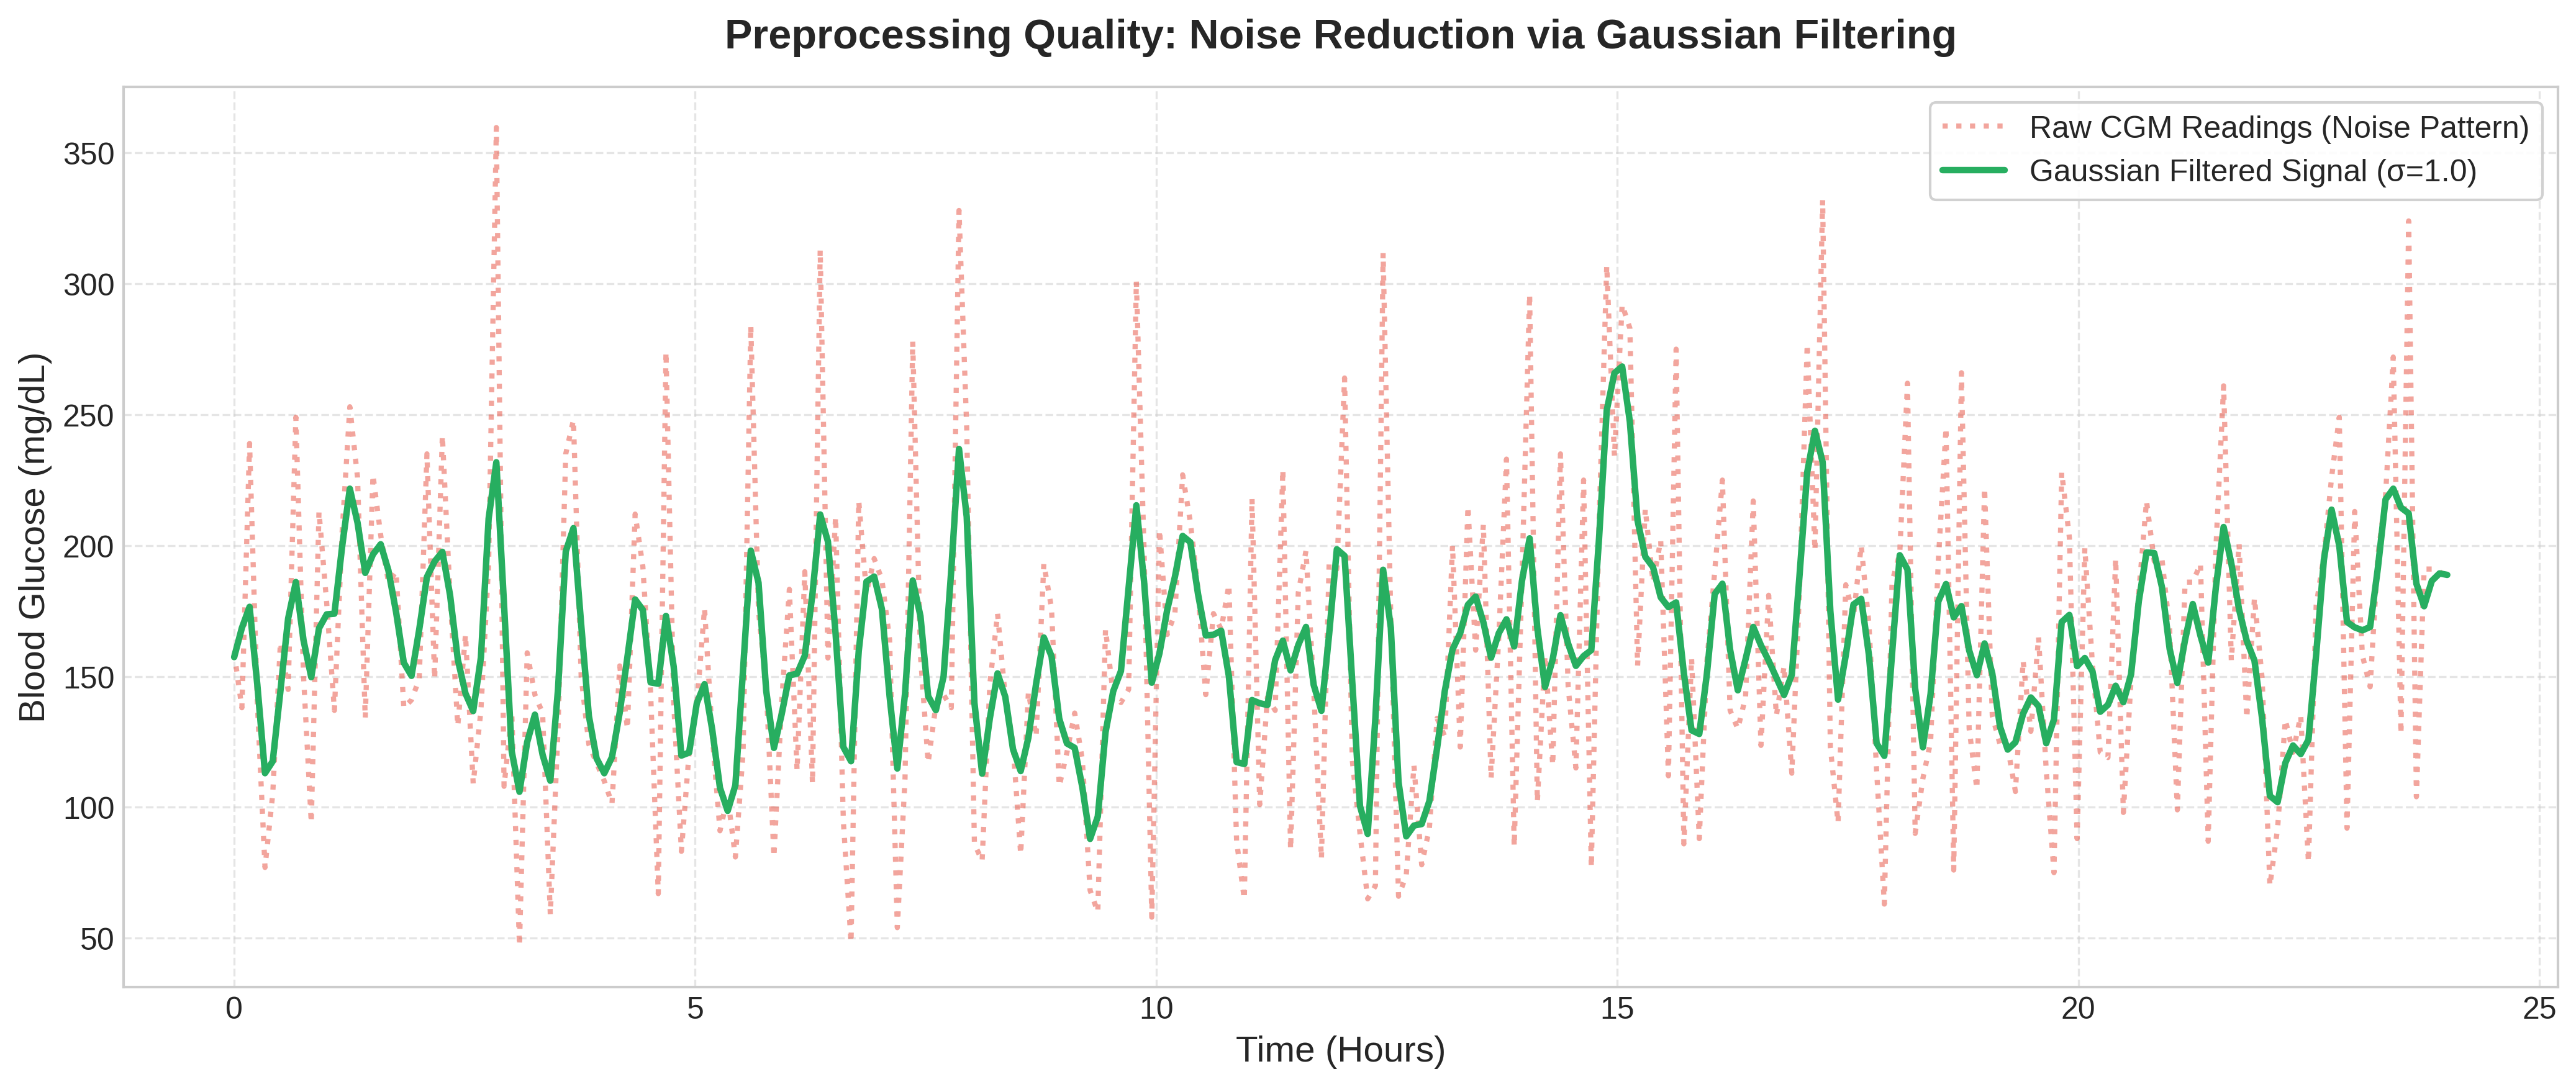

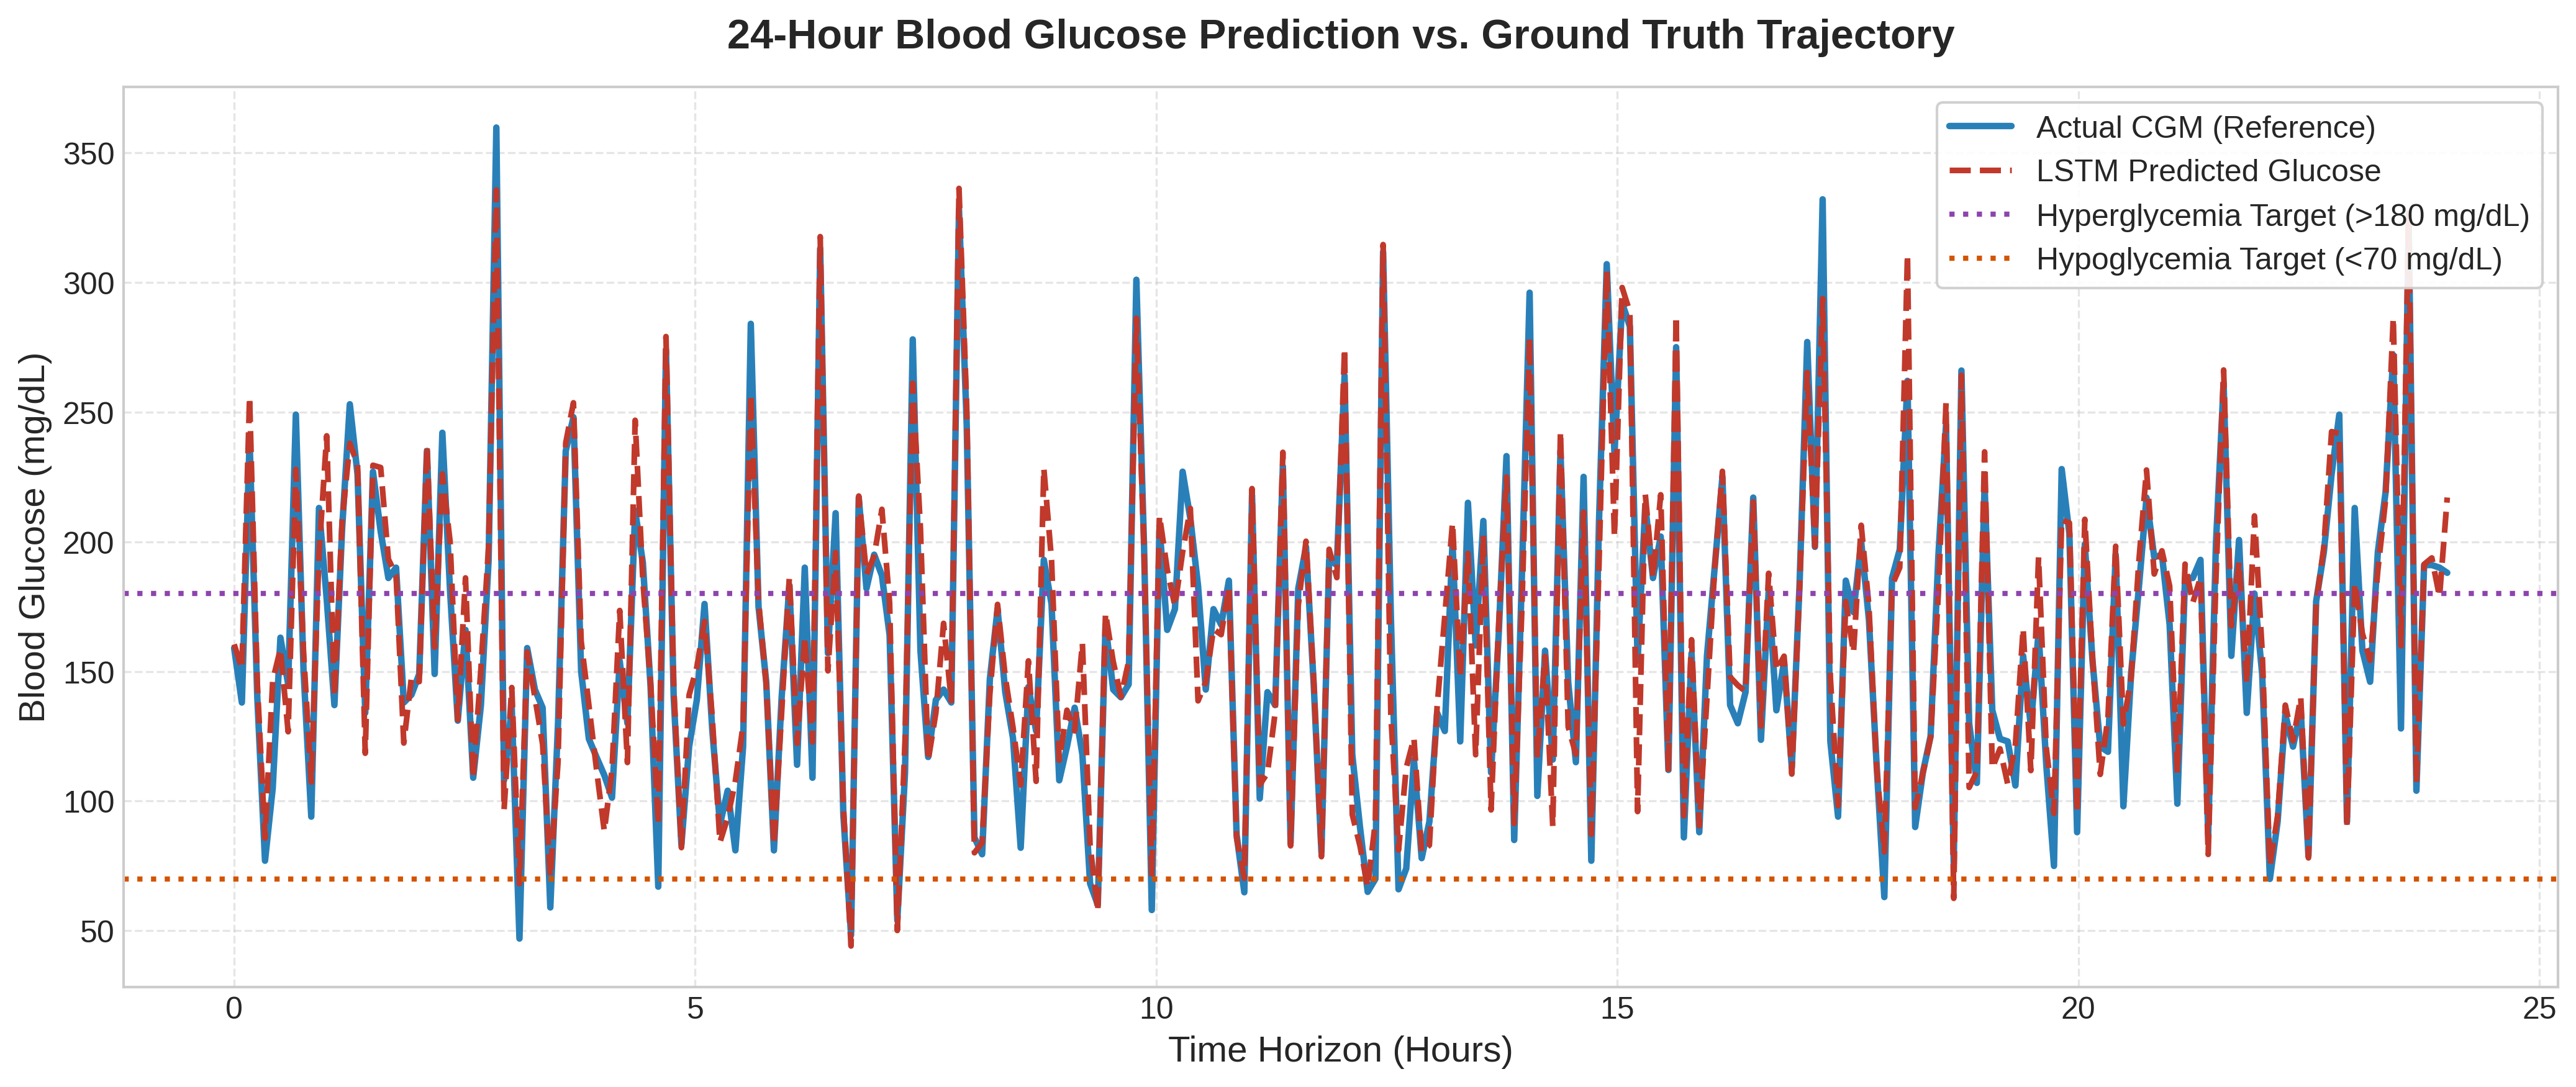

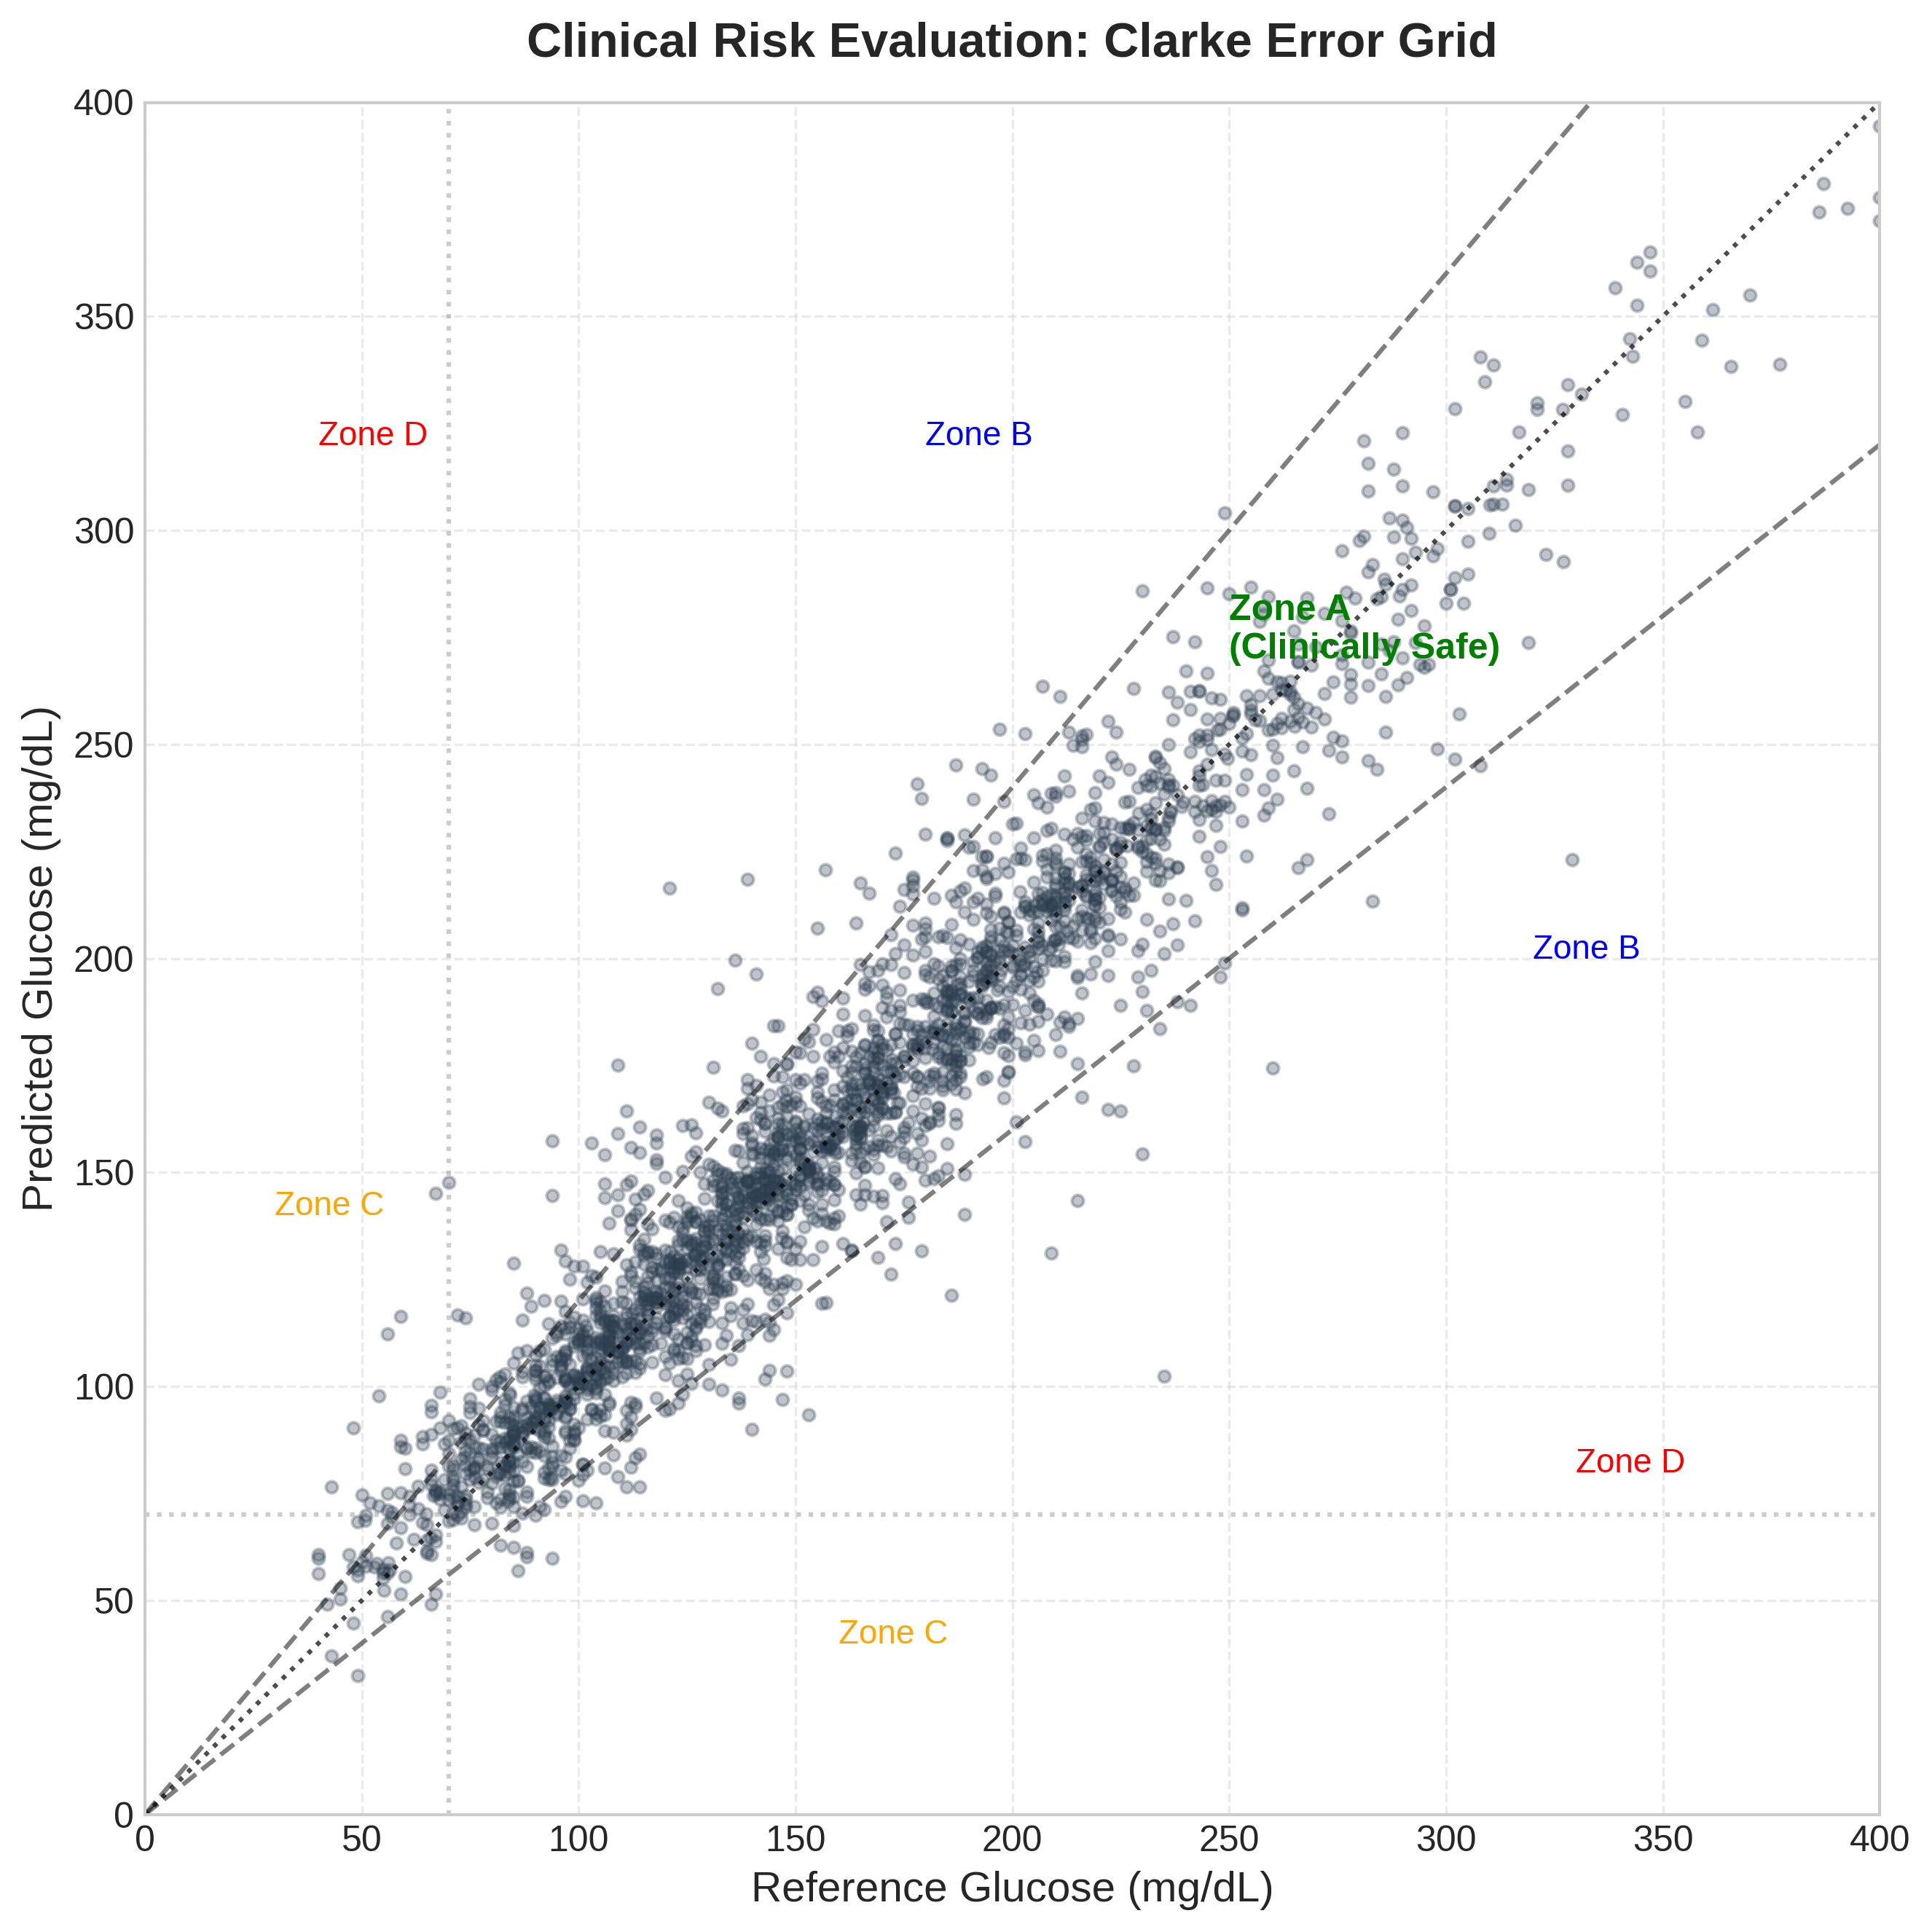

✅ High-resolution plots successfully rendered and saved as PNGs!


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.ndimage import gaussian_filter1d

# Apply high-resolution rendering and clear font formatting
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18
})

# ==========================================
# 1. RUN EVALUATION PASS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for b_main, b_base, b_time, b_y in test_loader:
        b_main, b_base, b_time = b_main.to(device), b_base.to(device), b_time.to(device)
        preds = model(b_main, b_base, b_time).squeeze()
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(b_y.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# ==========================================
# PLOT 1: RAW VS. GAUSSIAN SMOOTHED CGM SIGNAL
# ==========================================
plt.figure(figsize=(14, 6), dpi=300)

sample_steps = 288  # 24 hours of data (288 steps of 5 mins)
time_hours = np.linspace(0, 24, sample_steps)
raw_cgm_sample = all_targets[:sample_steps]
smoothed_cgm_sample = gaussian_filter1d(raw_cgm_sample, sigma=1.0)

plt.plot(time_hours, raw_cgm_sample, label='Raw CGM Readings (Noise Pattern)', 
         color='#e74c3c', alpha=0.5, linestyle=':', linewidth=2.0)
plt.plot(time_hours, smoothed_cgm_sample, label='Gaussian Filtered Signal (σ=1.0)', 
         color='#27ae60', linewidth=2.5)

plt.title("Preprocessing Quality: Noise Reduction via Gaussian Filtering", pad=15, fontweight='bold')
plt.xlabel("Time (Hours)")
plt.ylabel("Blood Glucose (mg/dL)")
plt.legend(loc="upper right", frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plot_1_preprocessing_smoothing.png", dpi=300)
plt.show()

# ==========================================
# PLOT 2: 24-HOUR TRAJECTORY TRACKING
# ==========================================
plt.figure(figsize=(14, 6), dpi=300)

plt.plot(time_hours, all_targets[:sample_steps], label='Actual CGM (Reference)', 
         color='#2980b9', linewidth=2.5)
plt.plot(time_hours, all_preds[:sample_steps], label='LSTM Predicted Glucose', 
         color='#c0392b', linestyle='--', linewidth=2.2)

# Clinical Boundaries
plt.axhline(y=180, color='#8e44ad', linestyle=':', linewidth=2, label='Hyperglycemia Target (>180 mg/dL)')
plt.axhline(y=70, color='#d35400', linestyle=':', linewidth=2, label='Hypoglycemia Target (<70 mg/dL)')

plt.title("24-Hour Blood Glucose Prediction vs. Ground Truth Trajectory", pad=15, fontweight='bold')
plt.xlabel("Time Horizon (Hours)")
plt.ylabel("Blood Glucose (mg/dL)")
plt.legend(loc="upper right", frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plot_2_trajectory_tracking.png", dpi=300)
plt.show()

# ==========================================
# PLOT 3: CLARKE ERROR GRID ANALYSIS
# ==========================================
plt.figure(figsize=(9, 9), dpi=300)

indices = np.random.choice(len(all_targets), min(2500, len(all_targets)), replace=False)
ref = all_targets[indices]
pred = all_preds[indices]

plt.scatter(ref, pred, c='#2c3e50', alpha=0.3, s=15, label='Inference Samples')

# Boundaries
plt.xlim(0, 400)
plt.ylim(0, 400)

plt.plot([0, 400], [0, 400], 'k:', alpha=0.7, label='Perfect Prediction')
plt.plot([0, 400], [0, 400 * 1.2], 'k--', alpha=0.5)
plt.plot([0, 400], [0, 400 * 0.8], 'k--', alpha=0.5)
plt.axhline(y=70, color='gray', linestyle=':', alpha=0.4)
plt.axvline(x=70, color='gray', linestyle=':', alpha=0.4)

# Zone Annotations
plt.text(250, 270, 'Zone A\n(Clinically Safe)', fontsize=12, fontweight='bold', color='green')
plt.text(320, 200, 'Zone B', fontsize=11, color='blue')
plt.text(180, 320, 'Zone B', fontsize=11, color='blue')
plt.text(160, 40, 'Zone C', fontsize=11, color='orange')
plt.text(30, 140, 'Zone C', fontsize=11, color='orange')
plt.text(330, 80, 'Zone D', fontsize=11, color='red')
plt.text(40, 320, 'Zone D', fontsize=11, color='red')

plt.title("Clinical Risk Evaluation: Clarke Error Grid", pad=15, fontweight='bold')
plt.xlabel("Reference Glucose (mg/dL)")
plt.ylabel("Predicted Glucose (mg/dL)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("plot_3_clarke_error_grid.png", dpi=300)
plt.show()

print("✅ High-resolution plots successfully rendered and saved as PNGs!")